In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import pandas as pd
from sklearn.ensemble import IsolationForest
from scipy.linalg import lstsq
from sklearn.model_selection import train_test_split
import cvxpy as cp
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401


In [9]:
df_data = pd.read_parquet("../training_data/initial_dataset.parquet")
df_train_detached = pd.read_parquet(
    "../training_data/data_detached_with_weather.parquet")
type(df_data)
type(df_train_detached)
df_train_detached

unique_ids = df_train_detached["Property_ID"].unique()
id_use = unique_ids[0]


df_house = pd.read_csv('../training_data/home_characteristics.csv')

# List of columns to check for missingness
cols = [
    "Bedrooms", "Floor_Height", "Habitable_Rooms", "House_Age",
    "House_Form", "No_Storeys", "No_Underfloor",
    "Total_Floor_Area", "Wall_Type", "MCS_DHWAnnual","HP_Size_kW"
]

# calculate min capacity in home 
cp_air = 1.005  #kJ/kgK
rho_air = 1.225  # kg/m^3
kj_to_kWh = 1/3600
df_house["Volume"] = df_house["Total_Floor_Area"] * df_house["Floor_Height"]
df_house["Min Capacity"] = df_house["Volume"] * cp_air * rho_air * kj_to_kWh

df_home_values = df_house[df_house["Property_ID"].isin(unique_ids)]

summary = df_home_values[["Property_ID", "Min Capacity"]].drop_duplicates()
print(summary)

home_dict = df_home_values.set_index("Property_ID").to_dict(orient="index")

     Property_ID  Min Capacity
76       EOH3196      0.086941
318      EOH0413      0.094570
585      EOH2329      0.099645
736      EOH1637      0.088733
1149     EOH3154      0.116411
1156     EOH2675      0.124696
1569     EOH1485      0.115696
1692     EOH0546      0.088239
2066     EOH0279      0.138493
2381     EOH1703      0.074688


In [10]:
df_single = df_train_detached[
df_train_detached["Property_ID"] == id_use].copy()

#re-adjust Heat Pump Diff and add temp differences
df_single["Heat_Pump_Energy_Output_Diff"] = df_single[
    "Heat_Pump_Energy_Output"].diff()
df_single["Internal_Temperature_Diff"] = df_single[
    "Internal_Air_Temperature"].diff()
df_single["Internal_Ambient_Temperature_Diff"] = \
    (df_single["External_Air_Temperature"] -
     df_single["Internal_Air_Temperature"])

# 1. Drop columns with almost all missing data (e.g., more than 90% missing)
threshold = 0.90 * len(df_single)
df_single_cleaned = df_single.dropna(axis=1, thresh=threshold)
#print("Columns dropped due to high missing values:")
#print(df_single.columns.difference(df_single_cleaned.columns).tolist())

df_single = df_single_cleaned

#print("\nColumns remaining after dropping highly missing columns:")
#print(df_single.columns.tolist())

df_single = df_single.set_index('Timestamp')
df_single = df_single.sort_index()

# Apply interpolation with a limit of 4 (for 2 hours of half-hourly data)
numeric_cols = df_single.select_dtypes(include=['number']).columns
df_single_numeric_interpolated = df_single[numeric_cols].interpolate(
    method='time', limit=4, limit_direction='both')

df_single_interpolated = df_single.copy()
df_single_interpolated[numeric_cols] = df_single_numeric_interpolated

# After interpolation, drop rows that still contain NaN values (meaning they were missing for > 2 hours)
initial_rows = len(df_single_interpolated)
df_single_processed = df_single_interpolated.dropna()

In [11]:
df_heating_single = df_single_processed.copy()

# Time range
t_start = pd.to_datetime("2021-10-01 00:00:00")
t_end = pd.to_datetime("2022-3-31 23:59:00")
df_heating_only = df_heating_single[
    (df_heating_single.index >= t_start) & (df_heating_single.index <= t_end)
].copy()

df_heating_only.drop("Property_ID", axis=1, inplace=True)
df_heating_only.drop("half-hour", axis=1, inplace=True)
df_heating_only.drop("Date", axis=1, inplace=True)
df_heating_only.drop("has_data", axis=1, inplace=True)

    


In [12]:
# thresholds
q_min = 2.0                 # example value
delta_T_i_min = 0.0         # example value (°C)
n_steps_ahead_T = 1           # how many future steps to look at
n_steps_q = 1
# --- your existing prep work (shortened) ---
t_start = pd.to_datetime("2021-10-01 00:00:00")
t_end   = pd.to_datetime("2022-03-31 23:59:00")

df = df_heating_single.loc[t_start:t_end].copy()
df['sin_h'] = np.sin(2 * np.pi * df.index.hour / 24)
df['cos_h'] = np.cos(2 * np.pi * df.index.hour / 24)

agg_dict = {
    'Heat_Pump_Energy_Output_Diff': 'sum',
    'Internal_Ambient_Temperature_Diff': 'mean',
    'Internal_Temperature_Diff': 'mean',
    'Internal_Air_Temperature': 'mean',
}
df_retime = df.resample('1h').agg(agg_dict).dropna()

# --- flagging logic ---
temp_now = df_retime['Internal_Air_Temperature']
q_now    = df_retime['Heat_Pump_Energy_Output_Diff']

# max future ΔT over the next n steps
future_dT = pd.concat([temp_now.shift(-k) - temp_now
                       for k in range(1, n_steps_ahead_T + 1)], axis=1)
max_future_delta = future_dT.max(axis=1)

# any big Q in the next/prev n steps?
future_q = pd.concat([q_now.shift(-k) for k in range(1, n_steps_q + 1)], axis=1)
prev_q   = pd.concat([q_now.shift(+k) for k in range(1, n_steps_q + 1)], axis=1)

has_big_q_future = future_q.gt(q_min).any(axis=1)
has_big_q_prev   = prev_q.gt(q_min).any(axis=1)

# base condition
base_flag = (q_now > q_min) & (max_future_delta < delta_T_i_min)

# exclude if big Q just before OR after
flag = base_flag & ~(has_big_q_future | has_big_q_prev)

df_retime['no_temp_rise_flag']  = flag
df_retime['flagged_heat_input'] = np.where(flag, q_now, 0.0)

# handle edges where look-ahead/look-behind is impossible
idx_tail = df_retime.tail(max(n_steps_ahead_T, n_steps_q)).index
idx_head = df_retime.head(n_steps_q).index
df_retime.loc[idx_tail.union(idx_head), ['no_temp_rise_flag','flagged_heat_input']] = [False, 0.0]

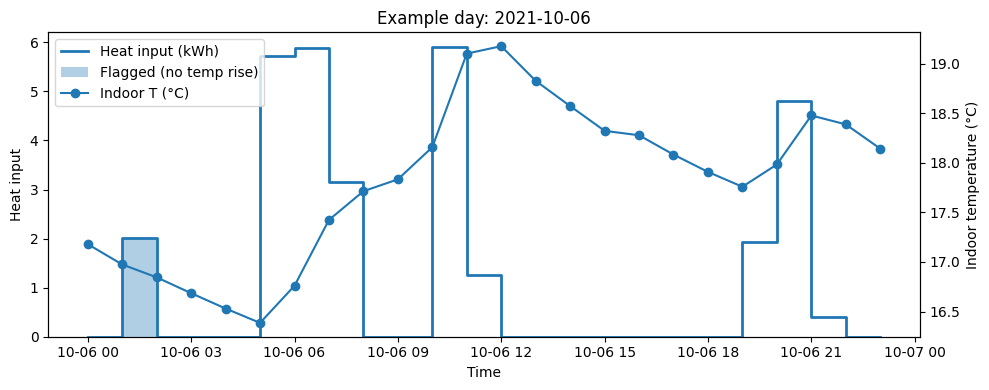

In [15]:
# --- find an example day with a flag ---
flagged_days = df_retime.index[df_retime['no_temp_rise_flag']].normalize().unique()
if len(flagged_days) == 0:
    raise ValueError("No flagged timesteps found. Relax thresholds or check data.")
example_day = flagged_days[4]   # just take the first; or pick one manually

day_slice = df_retime.loc[example_day: example_day + pd.Timedelta(days=1) - pd.Timedelta(seconds=1)]

# --- plot ---
fig, ax1 = plt.subplots(figsize=(10, 4))

# heat input (left axis)
ax1.step(day_slice.index, day_slice['Heat_Pump_Energy_Output_Diff'],
         where='post', label='Heat input (kWh)', linewidth=2)
ax1.set_ylabel('Heat input')
ax1.set_xlabel('Time')

mask = day_slice['no_temp_rise_flag'].fillna(False)
width = (day_slice.index.to_series().diff().median() or pd.Timedelta('1H'))

ax1.bar(
    day_slice.index[mask],
    day_slice['Heat_Pump_Energy_Output_Diff'][mask],
    width=width,
    align='edge',
    alpha=0.35,
    label='Flagged (no temp rise)'
)

# indoor temperature (right axis)
ax2 = ax1.twinx()
ax2.plot(day_slice.index, day_slice['Internal_Air_Temperature'],
         marker='o', linestyle='-', label='Indoor T (°C)')
ax2.set_ylabel('Indoor temperature (°C)')

# legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title(f'Example day: {example_day.date()}')
plt.tight_layout()

In [14]:
print("Flags in this day:", day_slice['no_temp_rise_flag'].sum())


Flags in this day: 1
